In [4]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [5]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [6]:
NUM_CLASSES = 0
with open('model/keypoint_classifier/keypoint_classifier_label.csv',encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    data = list(reader)
    NUM_CLASSES = len(data)
print(NUM_CLASSES)

39


# Dataset reading

In [7]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (42 * 2) + 1)))

In [8]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.85, random_state=RANDOM_SEED)



# Model building

In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((42 * 2, )),
    #tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(42, activation='relu'),
    #tf.keras.layers.Dropout(0.4),
   # tf.keras.layers.Dense(21, activation='relu'),
    #tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    #tf.keras.layers.Dense(5, activation='relu'),
    #tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 42)                3570      
                                                                 
 dense_1 (Dense)             (None, 10)                430       
                                                                 
 dense_2 (Dense)             (None, 20)                220       
                                                                 
 dense_3 (Dense)             (None, 39)                819       
                                                                 
Total params: 5039 (19.68 KB)
Trainable params: 5039 (19.68 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [14]:
model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=1000,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback],
)

Epoch 1/1000
445/449 [============================>.] - ETA: 0s - loss: 1.3680 - accuracy: 0.6289
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
449/449 [==============================] - 4s 7ms/step - loss: 1.3594 - accuracy: 0.6311 - val_loss: 0.3629 - val_accuracy: 0.9003
Epoch 2/1000
  9/449 [..............................] - ETA: 2s - loss: 0.3465 - accuracy: 0.9045

c:\SignAI-Sign-Language-Recognition-and-Translation-main\SignAI\venv\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


443/449 [============================>.] - ETA: 0s - loss: 0.2114 - accuracy: 0.9493
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
449/449 [==============================] - 3s 8ms/step - loss: 0.2101 - accuracy: 0.9496 - val_loss: 0.1263 - val_accuracy: 0.9771
Epoch 3/1000
440/449 [============================>.] - ETA: 0s - loss: 0.0882 - accuracy: 0.9820
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
449/449 [==============================] - 2s 5ms/step - loss: 0.0877 - accuracy: 0.9822 - val_loss: 0.0640 - val_accuracy: 0.9874
Epoch 4/1000
437/449 [============================>.] - ETA: 0s - loss: 0.0479 - accuracy: 0.9922
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
449/449 [==============================] - 2s 5ms/step - loss: 0.0475 - accuracy: 0.9923 - val_loss: 0.0418 - val_accuracy: 0.9942
Epoch 5/1000
437/449 [============================>.] - ETA: 0s - loss: 0.0302 - accuracy: 0.9957


In [15]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

80/80 [==============================] - 0s 3ms/step - loss: 0.0248 - accuracy: 0.9978


In [16]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [17]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))
x = np.argmax(np.squeeze(predict_result))
print(np.squeeze(predict_result)[x])

1/1 [==============================] - 0s 110ms/step
[2.6296819e-08 3.5716944e-08 8.4824549e-19 1.7033485e-19 1.9053488e-32
 9.4956229e-19 1.4820581e-12 4.3084372e-10 1.4725437e-07 1.4198602e-12
 7.6220802e-15 1.8307037e-36 7.9488129e-22 3.9826066e-15 2.5237399e-09
 1.2664596e-10 1.6867355e-06 7.3268734e-36 1.0353959e-15 8.0666801e-10
 2.1303473e-21 1.1243404e-15 2.8302923e-30 4.4318114e-09 2.2780082e-10
 9.9999762e-01 1.8745850e-18 1.2156860e-18 8.1076951e-10 1.2515352e-14
 3.1740598e-08 2.5249488e-16 7.8199240e-18 5.0044097e-10 5.3826074e-07
 8.0105519e-13 2.7370239e-16 4.7360241e-19 7.2822285e-15]
25
0.9999976


# Confusion matrix

317/317 [==============================] - 1s 2ms/step


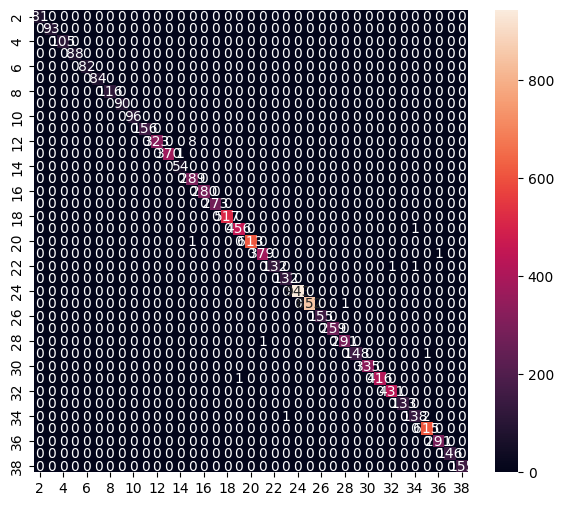

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [19]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

c:\SignAI-Sign-Language-Recognition-and-Translation-main\SignAI\venv\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [20]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\saroj\AppData\Local\Temp\tmp0z9vln5d\assets


INFO:tensorflow:Assets written to: C:\Users\saroj\AppData\Local\Temp\tmp0z9vln5d\assets


12160

# Inference test

In [21]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [22]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [23]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [24]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 15.6 ms
Wall time: 3.01 ms


In [25]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[2.6514085e-08 3.6241147e-08 9.3520440e-19 1.7066327e-19 1.8955040e-32
 9.3487622e-19 1.5117530e-12 4.6245177e-10 1.5664266e-07 1.5043319e-12
 8.2506794e-15 1.8442171e-36 7.8750487e-22 3.8854248e-15 2.3437805e-09
 1.2615821e-10 1.7425831e-06 6.8380495e-36 1.0335962e-15 7.8043089e-10
 2.0977670e-21 1.1484595e-15 2.6616546e-30 4.9255000e-09 2.0791444e-10
 9.9999750e-01 1.7628983e-18 1.1922271e-18 7.8068996e-10 1.1410972e-14
 2.9705131e-08 2.5647694e-16 7.7238668e-18 4.7503762e-10 5.5497736e-07
 8.2561036e-13 2.6169716e-16 4.6813470e-19 6.9675427e-15]
25
